In [4]:
pip install "transformers<5"

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
from transformers import GPT2LMHeadModel

model_hf = GPT2LMHeadModel.from_pretrained("gpt2")
sd_hf = model_hf.state_dict()

for k, v in sd_hf.items():
    print(k, v.shape)

transformer.wte.weight torch.Size([50257, 768])
transformer.wpe.weight torch.Size([1024, 768])
transformer.h.0.ln_1.weight torch.Size([768])
transformer.h.0.ln_1.bias torch.Size([768])
transformer.h.0.attn.c_attn.weight torch.Size([768, 2304])
transformer.h.0.attn.c_attn.bias torch.Size([2304])
transformer.h.0.attn.c_proj.weight torch.Size([768, 768])
transformer.h.0.attn.c_proj.bias torch.Size([768])
transformer.h.0.ln_2.weight torch.Size([768])
transformer.h.0.ln_2.bias torch.Size([768])
transformer.h.0.mlp.c_fc.weight torch.Size([768, 3072])
transformer.h.0.mlp.c_fc.bias torch.Size([3072])
transformer.h.0.mlp.c_proj.weight torch.Size([3072, 768])
transformer.h.0.mlp.c_proj.bias torch.Size([768])
transformer.h.1.ln_1.weight torch.Size([768])
transformer.h.1.ln_1.bias torch.Size([768])
transformer.h.1.attn.c_attn.weight torch.Size([768, 2304])
transformer.h.1.attn.c_attn.bias torch.Size([2304])
transformer.h.1.attn.c_proj.weight torch.Size([768, 768])
transformer.h.1.attn.c_proj.bias 

In [3]:
sd_hf["transformer.wpe.weight"].view(-1)[:20]

tensor([-0.0188, -0.1974,  0.0040,  0.0113,  0.0638, -0.1050,  0.0369, -0.1680,
        -0.0491, -0.0565, -0.0025,  0.0135, -0.0042,  0.0151,  0.0166, -0.1381,
        -0.0063, -0.0461,  0.0267, -0.2042])

In [8]:
pip install matplotlib

  Using cached pillow-12.1.0-cp310-cp310-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (8.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 8.7 MB/s  0:00:006m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 8.5 MB/s  0:00:00m eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 7.6 MB/s  0:00:00m eta 0:00:01
Using cached pillow-12.1.0-cp310-cp310-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (7.0 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]7 [matplotlib]
Note: you may need to restart the kernel to use updated packages.


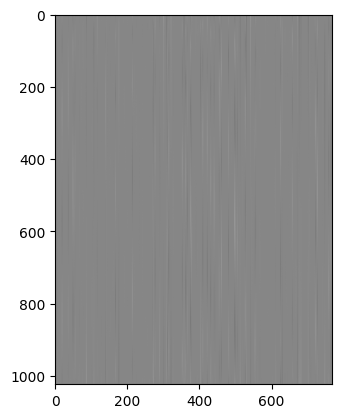

In [9]:
import matplotlib.pyplot as plt

plt.imshow(sd_hf["transformer.wpe.weight"], cmap="gray")

In [ ]:
from transformers import pipeline, set_seed

generator = pipeline("text-generation", model="gpt2")
set_seed(42)

generator("Hello, roses are red, buttons are blue and jumping  mice are", max_length=30, num_return_sequences=5)

'(ReadTimeoutError("HTTPSConnectionPool(host='huggingface.co', port=443): Read timed out. (read timeout=10)"), '(Request ID: 2591c537-c2d4-40da-ae81-da99c2b6635c)')' thrown while requesting HEAD https://huggingface.co/gpt2/resolve/main/config.json
Retrying in 1s [Retry 1/5].
Device set to use cpu
Truncation was not explicitly activated but `max_length` is provided a specific value, please use `truncation=True` to explicitly truncate examples to max length. Defaulting to 'longest_first' truncation strategy. If you encode pairs of sequences (GLUE-style) with the tokenizer you can select this strategy more precisely by providing a specific strategy to `truncation`.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=30) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[{'generated_text': "Hello, roses are red, buttons are blue and jump mice are green. I want it to be that way, and I think it would be nice to have the color scheme that is more subtle and it would get a bit more consistent with the art. But it would also have the appearance that I think would be the best way to showcase the colors.\n\nI'm not really sure if I'm going to keep making it. I'll try to keep it consistent, but I'm not sure if it's going to fit what I'm trying to do. I'm not really sure if I'm going to keep making it. I'll try to keep it consistent, but I'm not sure if it's going to fit what I'm trying to do.\n\nQ: How is the process for making a palette different for each character?\n\nA: It's a little bit different. I do like to work on characters who are very different. I'm not sure how I'll feel if some of these characters are more similar to me, or if they're more alike, but it's really all about that.\n\nQ: Do you have a favorite character from the past that you are wo

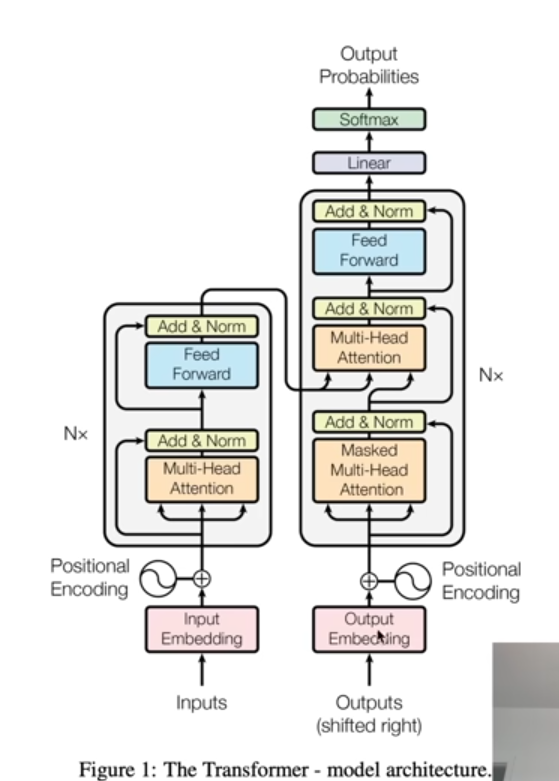

In [13]:
from dataclasses import dataclass
import torch
import torch.nn as nn
from torch.nn import functional as F
import math

@dataclass
class GPTConfig:
        block_size: int = 1024
        vocab_size: int = 50257
        n_layer: int = 12
        n_head: int = 12
        n_embd: int = 768


class Block(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.ln_1 = nn.LayerNorm(config.n_embd)
        self.attn = CausalSelfAttention(config)
        self.ln_2 = nn.LayerNorm(config.n_embd)
        self.mlp  = MLP(config)

    def forward(self, x):
        x = x + self.attn(self.ln_1(x))
        x = x + self.mlp(self.ln_2(x))
        return x

class MLP(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.c_fc = nn.Linear(config.n_embd, 4 * config.n_embd)
        # GELU looks like RELU(x) = max(x, 0) but is smooth at 0
        self.gelu = nn.GELU(approximate='tanh')
        self.c_proj = nn.Linear(4 * config.n_embd, config.n_embd)

    def forward(self, x):
        x = self.c_fc(x)
        x = self.gelu(x)
        x = self.c_proj(x)
        return x

class CausalSelfAttention(nn.Module):

    def __init__(self, config):
        super().__init__()
        assert config.n_embd % config.n_head == 0
        self.c_attn = nn.Linear(config.n_embd, 3 * config.n_embd)
        self.c_proj = nn.Linear(config.n_embd, config.n_embd)

        self.n_head = config.n_head
        self.n_embd = config.n_embd

        self.register_buffer("bias", torch.tril(torch.ones(config.block_size, config.block_size)).view(1, 1, config.block_size, config.block_size))

    def forward(self, x):
        B, T, C = x.size()

        qkv = self.c_attn(x)
        q, k, v = qkv.split(self.n_embd, dim=2)

        # Instead of defining a single Head, running multiple Heads in parallel and concatenating their outputs
        # We define the multi-headed attention as a single matmul and divide treat the heads as batches
        k = k.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)
        q = q.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)
        v = v.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)

        att = (q @ k.transpose(-2, -1)) * (1.0 / math.sqrt(k.size(-1)))
        att = att.masked_fill(self.bias[:, :, :T, :T] == 0, float('-inf'))
        att = F.softmax(att, dim=-1)
        y = att @ v
        y = y.transpose(1, 2).contiguous().view(B, T, C)
        y = self.c_proj(y)

        return y

class GPT(nn.Module):

    def __init__(self, config):
        super().__init__()
        self.config = config

        self.transformer = nn.ModuleDict(dict(
              wte = nn.Embedding(config.vocab_size, config.n_embd),
              wpe = nn.Embedding(config.block_size, config.n_embd),
              h = nn.ModuleList([Block(config) for _ in range(config.n_layer)]),
              ln_f = nn.LayerNorm(config.n_embd),
        ))

        self.lm_head = nn.Linear(config.n_embd, config.vocab_size, bias=False)

    @classmethod
    def from_pretrained(cls, model_type):
        assert model_type in {'gpt2', 'gpt2-medium', 'gpt2-large', 'gpt2-xl'}
        from transformers import GPT2LMHeadModel

        print("Loading weights from pretrained gpt: %s" % model_type)

        config_args = {
            'gpt2': dict(n_layer=12, n_head=12, n_embd=768)
        }[model_type]

        config_args['vocab_size'] = 50257
        config_args['block_size'] = 1024

        # create a from-scratch initialized minGPT model
        config = GPTConfig(**config_args)
        model = GPT(config)
        sd = model.state_dict()
        sd_keys = sd.keys()
        sd_keys = [k for k in sd_keys if not k.endswith('.attn.bias')] # discard this mask / buffer, not a param

        # init a huggingface/transformers model
        model_hf = GPT2LMHeadModel.from_pretrained(model_type)
        sd_hf = model_hf.state_dict()

        # copy while ensuring all of the parameters are aligned and match in names and shapes
        sd_keys_hf = sd_hf.keys()
        sd_keys_hf = [k for k in sd_keys_hf if not k.endswith('.attn.masked_bias')] # ignore these, just a buffer
        sd_keys_hf = [k for k in sd_keys_hf if not k.endswith('.attn.bias')] # same, just the mask (buffer)
        transposed = ['attn.c_attn.weight', 'attn.c_proj.weight', 'mlp.c_fc.weight', 'mlp.c_proj.weight']
        # basically the openai checkpoints use a "Conv1D" module, but we only want to use a vanilla Linear
        # this means that we have to transpose these weights when we import them
        assert len(sd_keys_hf) == len(sd_keys), f"mismatched keys: {len(sd_keys_hf)} != {len(sd_keys)}"
        for k in sd_keys_hf:
            if any(k.endswith(w) for w in transposed):
                # special treatment for the Conv1D weights we need to transpose
                assert sd_hf[k].shape[::-1] == sd[k].shape
                with torch.no_grad():
                    sd[k].copy_(sd_hf[k].t())
            else:
                # vanilla copy over the other parameters
                assert sd_hf[k].shape == sd[k].shape
                with torch.no_grad():
                    sd[k].copy_(sd_hf[k])

        return model

    def forward(self, idx):
        B, T = idx.size()
        assert T <= self.config.block_size, f"Cannot forward sequence of length {T}, blocks size is {self.config.block_size}"

        pos = torch.arange(0, T, dtype=torch.long, device = idx.device)

        pos_emb = self.transformer.wpe(pos)
        tok_emb = self.transformer.wte(idx)

        x = tok_emb + pos_emb

        for block in self.transformer.h:
            x = block(x)

        x = self.transformer.ln_f(x)
        logits = self.lm_head(x)
        return logits

model = GPT.from_pretrained('gpt2')
print("Success")

Loading weights from pretrained gpt: gpt2
Success


## Predict words

In [65]:
import tiktoken

device = "cpu"

if torch.cuda.is_available():
    device = "cuda"
print("Using device: ", device)

num_return_sequences = 5
max_length = 30
model = GPT(GPTConfig())#.from_pretrained('gpt2')
model.eval()
model.to('cpu')

enc = tiktoken.get_encoding('gpt2')
tokens = enc.encode("Hello, I'm a language model,")

tokens = torch.tensor(tokens, dtype=torch.long)
tokens = tokens.unsqueeze(0).repeat(num_return_sequences, 1)
x = tokens.to('cpu')


torch.manual_seed(42)
torch.cuda.manual_seed(42)


while x.size(1) < max_length:
    with torch.no_grad():
        logits = model(x)

        logits = logits[:, -1, :]
        probs = F.softmax(logits, dim=-1)

        topk_probs, topk_indices = torch.topk(probs, 50, dim=-1)

        ix = torch.multinomial(topk_probs, 1)

        xcol = torch.gather(topk_indices, -1, ix)
        x = torch.cat((x, xcol), dim=1)


In [66]:
for i in range(num_return_sequences):
    tokens = x[i, :max_length].tolist()
    decoded = enc.decode(tokens)
    print(">", decoded)

> Hello, I'm a language model, Jr tranceraf athe subwayiboescap taps Gemini Pitapters injected kingdomURES sourced grids Speak Recoverost scrub solve understandably
> Hello, I'm a language model, Mahm Hok improbable Washington photographs pledgingscience worsened51 frank reel Rab fueledobosAAF1969 Winnipegvisors AcidUsually Beacon utilization
> Hello, I'm a language model, Hasan HastAttorneywater 1923 Temperature Jama deposit 670 maximum wage Guang PuzzleBrook Purdue expires� frivolous231Fed threaded performing
> Hello, I'm a language model,ェ Jeanneuggle Helen Serge memoriesRootrane honmber amidst levels seesURESStock guarded Bailey existed OCT healbah410
> Hello, I'm a language model,ches Lindiped quickest glac Marcos GPAincreasing urgent procedures layers interrog jobs WHATcloth promisedpped northeasternfolkocused Traditionflower


## What do GPT2's semantic vector embeddings look like?

In [60]:
import tiktoken
enc = tiktoken.get_encoding("gpt2")

# All King, Queen, Man and Woman are encoded with a single token :)
# woman requires two tokens though
enc.encode("King"), enc.encode("Queen"), enc.encode("Man"), enc.encode("Woman")


([15708], [32466], [5124], [48081])

In [61]:
wte = model.transformer.wte.weight   # shape: [vocab, d_model]

def token_embedding(word):
    ids = enc.encode(word)
    # Take the mean of the embedding vectors if a word is split into multiple tokens
    return wte[ids].mean(dim=0)

token_embedding("King").shape

torch.Size([768])

In [62]:
# Check whether we can get to 'queen' in this example
king = token_embedding("King")
man = token_embedding("Man")
woman = token_embedding("Woman")

candidate = king - man + woman

def nearest_tokens(vec, top_k=20):
    sims = F.cosine_similarity(vec.unsqueeze(0), wte)
    topk = torch.topk(sims, top_k)
    return [enc.decode([i]) for i in topk.indices]

nearest_tokens(candidate)


['King',
 'Woman',
 'Queen',
 'Lady',
 ' King',
 'Women',
 'KING',
 ' KING',
 ' queen',
 ' Queen',
 'Pope',
 ' Woman',
 'Elizabeth',
 'quickShip',
 '\x1b',
 '\x01',
 '\x0b',
 '\x03',
 '\x02',
 '�']

Sweet. 

## Train ChatGPT 2

### Baby input

In [ ]:
import tiktoken


device = "cpu"

if torch.cuda.is_available():
    device = "cuda"
print("Using device: ", device)

# wget https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt
with open('input.txt', 'r', encoding='utf-8') as f:
    data = f.read()

enc = tiktoken.get_encoding("gpt2")

tokens = enc.encode(data)

print(tokens[:24])

[5962, 22307, 25, 198, 8421, 356, 5120, 597, 2252, 11, 3285, 502, 2740, 13, 198, 198, 3237, 25, 198, 5248, 461, 11, 2740, 13]
